Объединение файлов вопрос-ответ в один файл

In [1]:
pip install python-docx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 1.3 MB/s eta 0:00:00


In [2]:
import re
import requests
import os
import io
import tempfile
from docx import Document

In [ ]:
#Код для Apps Script для получения списка файлов Вопрос-ответ и их ID
'''
function listFilesInFolder() {
  var folder = DriveApp.getFolderById('1VgSlecqOQs07cN99_CCpAxIRIAnGEQfm');
  var files = folder.getFiles();

  // Создаем новый txt-файл
  var file = DriveApp.createFile('Vopros-otvet_01_05.txt', '');

  // Получаем доступ к содержимому файла
  var fileContent = file.getBlob().getDataAsString();

  while (files.hasNext()) {
    var fileInFolder = files.next();
    // Записываем информацию о файле в txt-файл
    fileContent += fileInFolder.getName() + ': ' + fileInFolder.getId() + '\n';
  }

  // Записываем обновленное содержимое обратно в файл
  file.setContent(fileContent);
}
'''

In [3]:
# Перечень вопросов-ответов сохранен в файле Vopros-otvet01_05.txt, его ID 1fWcBZmCpJXeyZU3ywku4M3j6XiYiZnEo
id_FileList_txt = '1fWcBZmCpJXeyZU3ywku4M3j6XiYiZnEo'

In [4]:
# функция для загрузки документа по doc_id из гугл драйв в текстовом формате
def load_doc_id_text(file_id):
    # Download the document as plain text
    response = requests.get(f'https://drive.google.com/uc?export=download&id={file_id}')
    response.raise_for_status()
    text = response.text
    return text

In [5]:
# Выгрузим перечень нормативной документации
data_txt_id= load_doc_id_text(id_FileList_txt)
data_txt_id

'Требования к измерениям при проведении работ по ОТ.docx: 1NNyy-F-me8vkIv-fIbU1Yv6Qae0xUPcN\nСфера ГРОЕИ и судебные поручения.docx: 1a-n8fPdyosag_e7ELhAlnm-jrOJ9myLC\nО калибровке в нефтегазовой отрасли.docx: 1DlbnR57Y7rbtQPMegzeLLsKRTD3xb00e\nОб использовании СИ в сфере ГРОЕИ.docx: 1eQv4iruhgkaEsloHocWgGH0sGYtLw0EI\nО поверке и калибровке.docx: 1MXpsGH4VBXmqHsY_q8Oopgbf_sRivFAk\nОб отнесении к сфере ГРОЕИ.docx: 198YNIvt4QqJXDHDkRWigN3wP5MvNZ3-G\nО применении СИ в качестве эталона.docx: 1Vume803UtatPj-UqAzb4kh9qx2Ma7rEc\nО доработке процедуры поверки.docx: 1NqyRsz_GfqqOzi_IMot_3zeBV5qm4X-5\nОсобенности поверки СИ до 1993 г.docx: 1HmiQo9ypSU4OjjbXl-jxBnF3_WL2UFbg\nО выписке об УТ.docx: 1RB6oDpAh8R7DC6CJqnrUP440RhgcoJR4\nОтнесение к документам по стандартизации .docx: 1AjGMNdLKKPEPCRjmfj8Y9RSVE_V3_Zc1\nОб отказе в поверке счетчиков газа.docx: 1eDLpBBDUVBsOSSvWwG8Q0ROTea8-B6TH\nТрансформаторы_ТПЛ-10..docx: 1EFZBFugrBk1-KC9HLkzW50Pt_abaIdiu\nРазъяснения об удалении сведений о поверке из ФИ

In [6]:
#Cохраняем название файлов, данные ID в отдельную библиотеку python
# Создаем пустой словарь
file_dict = {}

# Используем регулярные выражения для поиска всех файлов и их ID
for file, id in re.findall(r'(.*): (.*)', data_txt_id):
    file_dict[file.strip()] = id.strip()

# Выводим словарь
file_dict

{'Требования к измерениям при проведении работ по ОТ.docx': '1NNyy-F-me8vkIv-fIbU1Yv6Qae0xUPcN',
 'Сфера ГРОЕИ и судебные поручения.docx': '1a-n8fPdyosag_e7ELhAlnm-jrOJ9myLC',
 'О калибровке в нефтегазовой отрасли.docx': '1DlbnR57Y7rbtQPMegzeLLsKRTD3xb00e',
 'Об использовании СИ в сфере ГРОЕИ.docx': '1eQv4iruhgkaEsloHocWgGH0sGYtLw0EI',
 'О поверке и калибровке.docx': '1MXpsGH4VBXmqHsY_q8Oopgbf_sRivFAk',
 'Об отнесении к сфере ГРОЕИ.docx': '198YNIvt4QqJXDHDkRWigN3wP5MvNZ3-G',
 'О применении СИ в качестве эталона.docx': '1Vume803UtatPj-UqAzb4kh9qx2Ma7rEc',
 'О доработке процедуры поверки.docx': '1NqyRsz_GfqqOzi_IMot_3zeBV5qm4X-5',
 'Особенности поверки СИ до 1993 г.docx': '1HmiQo9ypSU4OjjbXl-jxBnF3_WL2UFbg',
 'О выписке об УТ.docx': '1RB6oDpAh8R7DC6CJqnrUP440RhgcoJR4',
 'Отнесение к документам по стандартизации .docx': '1AjGMNdLKKPEPCRjmfj8Y9RSVE_V3_Zc1',
 'Об отказе в поверке счетчиков газа.docx': '1eDLpBBDUVBsOSSvWwG8Q0ROTea8-B6TH',
 'Трансформаторы_ТПЛ-10..docx': '1EFZBFugrBk1-KC9HLkz

In [7]:
# функция для загрузки документа по docx_id из гугл драйв в формате docx
def read_docx_from_id(docx_id):
    try:
        response = requests.get(f'https://docs.google.com/uc?export=download&id={docx_id}')
        file = io.BytesIO(response.content)
        document = Document(file)
        return document
    except Exception as e:
        print(f"Не удалось загрузить документ с id {docx_id}: {e}")
        return None

In [11]:
# функция для склейки документов по docx_id из гугл драйв в один файл формата docx c выводом наименования файла
def combine_word_documents(file_dict):
    merged_document = Document()  # создаем новый документ
    for index, (file_name, file_id) in enumerate(file_dict.items(), start=1):
        sub_doc = read_docx_from_id(file_id)  # открываем документ
        if sub_doc is not None:
            # добавляем нумерацию и наименование файла перед его содержимым
            merged_document.add_paragraph(f'{index}. {file_name}')
            for paragraph in sub_doc.paragraphs:
                merged_document.add_paragraph(paragraph.text)
    return merged_document

In [12]:
merged_document = combine_word_documents(file_dict)
merged_document.save('question_and_answer.docx')

In [14]:
# функция для склейки ответов документов по docx_id из гугл драйв в текст c выводом наименования файла для дальнейшей передачи в metadata
def combine_doc_answer(file_dict):
    merged_text = ""  # создаем новую строку
    for index, (file_name, file_id) in enumerate(file_dict.items(), start=1):
        sub_doc = read_docx_from_id(file_id)  # открываем документ
        if sub_doc is not None:
            # добавляем нумерацию и наименование файла перед его содержимым
            merged_text += f'# {file_name}\n'
            add_paragraph = False
            for paragraph in sub_doc.paragraphs:
                if paragraph.text.startswith('Ответ:'):
                    add_paragraph = True
                    continue
                if add_paragraph:
                    merged_text += paragraph.text + '\n'
    return merged_text

In [15]:
merged_text = combine_doc_answer(file_dict)

In [17]:
#запишем в файл
with open('answer.txt', 'w') as f:
    f.write(merged_text)

In [18]:
!pip install -q langchain_openai==0.0.2 faiss-cpu==1.7.4 openai==1.6.1 tiktoken==0.5.2 langchain_community==0.0.11 langchain==0.1.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 45.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.4/225.4 kB 23.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.0/798.0 kB 50.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.9/302.9 kB 27.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 23.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━

In [19]:
from langchain_openai import OpenAIEmbeddings
from langchain.text_splitter import CharacterTextSplitter
from langchain.vectorstores import FAISS
from langchain.text_splitter import RecursiveCharacterTextSplitter, MarkdownHeaderTextSplitter
from langchain.docstore.document import Document
import tiktoken
import matplotlib.pyplot as plt

In [21]:
def num_tokens_from_string(string: str, encoding_name: str) -> int:
      """Возвращает количество токенов в строке"""
      encoding = tiktoken.get_encoding(encoding_name)
      num_tokens = len(encoding.encode(string))
      return num_tokens

def split_text(text, max_count):
    headers_to_split_on = [
        ("#", "Header 1"),
    ]

    markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
    fragments = markdown_splitter.split_text(text)

    # Подсчет токенов для каждого фрагмента и построение графика
    fragment_token_counts = [num_tokens_from_string(fragment.page_content, "cl100k_base") for fragment in fragments]
    plt.hist(fragment_token_counts, bins=50, alpha=0.5, label='Fragments')
    plt.title('Распределение количества фрагментных токенов')
    plt.xlabel('Количество токенов')
    plt.ylabel('Частота')
    plt.show()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=max_count,
        chunk_overlap=0,
        length_function=lambda x: num_tokens_from_string(x, "cl100k_base")
    )

    source_chunks = [
        Document(page_content=chunk, metadata=fragment.metadata)
        for fragment in fragments
        for chunk in splitter.split_text(fragment.page_content)
    ]

    # Подсчет токенов для каждого source_chunk и построение графика
    source_chunk_token_counts = [num_tokens_from_string(chunk.page_content, "cl100k_base") for chunk in source_chunks]
    plt.hist(source_chunk_token_counts, bins=20, alpha=0.5, label='Source Chunks')
    plt.title('Распределение количества токенов исходного блока')
    plt.xlabel('Количество токенов')
    plt.ylabel('Частота')
    plt.show()

    return source_chunks, fragments

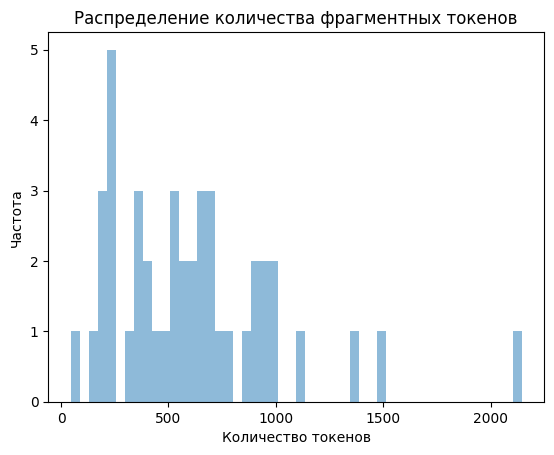

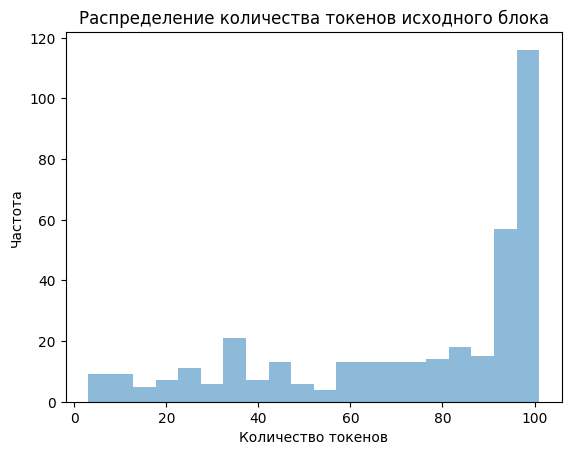

Общее количество чанков:  370
Первый чанк  page_content='Законодательство Российской Федерации об обеспечении единства измерений не устанавливает требования к лицам, осуществляющих работы по обеспечению безопасных условий и охраны труда.' metadata={'Header 1': 'Требования к измерениям при проведении работ по ОТ.docx'}
Крайний чанк  page_content='обязательные требования к эталонам единиц величин, применяемым вне сферы государственного регулирования обеспечения единства измерений, законодательством Российской Федерации об обеспечении единства измерений не предъявляются.' metadata={'Header 1': 'Об использовании СИ неутвержденного типа в качестве эталона..docx'}


In [49]:
source_chunks, fragments = split_text(merged_text, 100)
print("Общее количество чанков: ",len(source_chunks))
print("Первый чанк ", source_chunks[0])
print("Крайний чанк ", source_chunks[len(source_chunks)-1])

In [24]:
source_chunks[1]

Document(page_content='В соответствии с частью 1 статьи 9 Федерального закона от 26.06.2008\n№ 102-ФЗ «Об обеспечении единства измерений» (далее - Федеральный закон) в сфере государственного регулирования обеспечения единства измерений к применению допускаются средства измерений утвержденного типа, прошедшие поверку, а также обеспечивающие соблюдение установленных законодательством Российской Федерации об обеспечении единства измерений обязательных требований, включая обязательные метрологические требования к измерениям, обязательные метрологические и технические требования к средствам измерений, и установленных законодательством Российской Федерации о техническом регулировании обязательных требований.\nСфера государственного регулирования обеспечения единства измерений согласно пункту 16 части 3 статьи 1 Федерального закона распространяется на измерения, проводимые при выполнении поручений суда, органов прокуратуры, государственных органов исполнительной власти.\nКроме того, в соответ

In [26]:
from google.colab import userdata
# Получение API ключа из пользовательских данных Colab и установка его как переменной среды
key = userdata.get('OPENAI_API_KEY')
os.environ["OPENAI_API_KEY"] = key

In [27]:
import openai
from openai import OpenAI
# Создание клиента OpenAI с использованием API ключа из переменных среды
client = OpenAI()

In [28]:
# База знаний для Markdown сохранена в файле doc_markdown_v1.2.txt, его ID 17-_-kA8SVuAU5OM_2gkzGqw_lZ0Zc4yo
id_doc_markdown = '17-_-kA8SVuAU5OM_2gkzGqw_lZ0Zc4yo'
data_from_markdown = load_doc_id_text(id_doc_markdown)

In [29]:
def split_text_db(text, max_count):
    headers_to_split_on = [
        ("#", "Header 1"),
        ("##", "Header 2"),
        ("###", "Header 3"),
        ("####", "Header 4"),
    ]

    markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
    fragments = markdown_splitter.split_text(text)

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=max_count,
        chunk_overlap=0,
        length_function=lambda x: num_tokens_from_string(x, "cl100k_base")
    )

    source_chunks = [
        Document(page_content=chunk, metadata=fragment.metadata)
        for fragment in fragments
        for chunk in splitter.split_text(fragment.page_content)
    ]

    return source_chunks, fragments

In [66]:
source_chunks_db, fragments_db = split_text_db(data_from_markdown, 1000)
print("Общее количество чанков: ",len(source_chunks_db))
print("Первый чанк ", source_chunks_db[0])
print("Крайний чанк ", source_chunks_db[len(source_chunks_db)-1])

Общее количество чанков:  623
Первый чанк  page_content='Документ предоставлен КонсультантПлюс'
Крайний чанк  page_content='5. На оборотной стороне свидетельств о поверке при оформлении их на бумажном носителе или в свидетельствах о поверке, оформляемых в виде электронного документа, по заявлению владельцев средств измерений или лиц, представивших средства измерений на поверку, или по согласованию с ними может указываться дополнительная информация, относящаяся к средствам измерений, месту их установки, особенностям поверки, включая сведения о пломбах, предотвращающих доступ к местам настройки (регулировки) средств измерений, принадлежности средств измерений (сведения о владельцах средств измерений), а также информация о прилагаемых к свидетельству о поверке документах (при невозможности размещения информации на оборотной стороне свидетельства о поверке при оформлении его на бумажном носителе).' metadata={'Header 1': 'ТРЕБОВАНИЯ К СОДЕРЖАНИЮ СВИДЕТЕЛЬСТВА О ПОВЕРКЕ'}


In [67]:
# Инициализирум модель эмбеддингов
embeddings = OpenAIEmbeddings()

# Создадим индексную базу из разделенных фрагментов текста
db = FAISS.from_documents(source_chunks_db, embeddings)

In [39]:
#Выведем оценку расстояния для соответствия ответов (максимальный размер чанков = 1000) нормативной документации
import pandas as pd
file_dict_db_search = {}
k=1 #устанавливаем количество извлекаемых чанков
for i in range(len(source_chunks)):
    docs_and_scores = db.similarity_search_with_score(str(source_chunks[i].page_content), k=k)
    for j in range(k):
        file_dict_db_search[f"Вопрос {i}, ответ {j}"] = {
            "Ответ": str(source_chunks[i].page_content),
            "Файл ответа": str(source_chunks[i].metadata),
            "Контент нормативной документации": docs_and_scores[j][0].page_content,
            "Оценка расстояния": docs_and_scores[j][1]
        }
# Преобразование словаря в DataFrame
df_1000 = pd.DataFrame.from_dict(file_dict_db_search, orient='index')


In [40]:
df_1000.head()

,Ответ,Файл ответа,Контент нормативной документации,Оценка расстояния
"Вопрос 0, ответ 0",Законодательство Российской Федерации об обесп...,{'Header 1': 'Требования к измерениям при пров...,"6. Обязательные требования к измерениям, этало...",0.199487
"Вопрос 1, ответ 0",В соответствии с частью 1 статьи 9 Федеральног...,{'Header 1': 'Сфера ГРОЕИ и судебные поручения...,1. В сфере государственного регулирования обес...,0.062403
"Вопрос 2, ответ 0","При этом, при выполнении измерений в сфере гос...",{'Header 1': 'Сфера ГРОЕИ и судебные поручения...,5. Правительством Российской Федерации в целях...,0.116598
"Вопрос 3, ответ 0",Сфера государственного регулирования обеспечен...,{'Header 1': 'О калибровке в нефтегазовой отра...,1. В сфере государственного регулирования обес...,0.087452
"Вопрос 4, ответ 0",В связи с отсутствием в Вашем обращении информ...,{'Header 1': 'Об использовании СИ в сфере ГРОЕ...,1. В сфере государственного регулирования обес...,0.092385


Для чанков макс размера = 1000 ни одно из оценки векторных расстояний не превысило 0.4. Среденее значение = 0,13

In [41]:
# Сохранение DataFrame в excel-файл
df_1000.to_excel('answer_1000.xlsx')

In [46]:
#Выведем оценку расстояния для соответствия ответов (максимальный размер чанков = 500) нормативной документации
import pandas as pd
file_dict_db_search = {}
k=1 #устанавливаем количество извлекаемых чанков
for i in range(len(source_chunks)):
    docs_and_scores = db.similarity_search_with_score(str(source_chunks[i].page_content), k=k)
    for j in range(k):
        file_dict_db_search[f"Вопрос {i}, ответ {j}"] = {
            "Ответ": str(source_chunks[i].page_content),
            "Файл ответа": str(source_chunks[i].metadata),
            "Контент нормативной документации": docs_and_scores[j][0].page_content,
            "Оценка расстояния": docs_and_scores[j][1]
        }
# Преобразование словаря в DataFrame
df_500 = pd.DataFrame.from_dict(file_dict_db_search, orient='index')

In [47]:
df_500.head()

,Ответ,Файл ответа,Контент нормативной документации,Оценка расстояния
"Вопрос 0, ответ 0",Законодательство Российской Федерации об обесп...,{'Header 1': 'Требования к измерениям при пров...,--------------------------------\n<*> Обязател...,0.216860
"Вопрос 1, ответ 0","Например, в соответствии с пунктом 3 статьи 12...",{'Header 1': 'Требования к измерениям при пров...,--------------------------------\n<*> Обязател...,0.224215
"Вопрос 2, ответ 0",В соответствии с частью 1 статьи 9 Федеральног...,{'Header 1': 'Сфера ГРОЕИ и судебные поручения...,1. В сфере государственного регулирования обес...,0.056571
"Вопрос 3, ответ 0","Кроме того, в соответствии с частью 5 статьи 1...",{'Header 1': 'Сфера ГРОЕИ и судебные поручения...,5. Правительством Российской Федерации в целях...,0.071112
"Вопрос 4, ответ 0","При этом, при выполнении измерений в сфере гос...",{'Header 1': 'Сфера ГРОЕИ и судебные поручения...,5. Правительством Российской Федерации в целях...,0.108891


In [48]:
# Сохранение DataFrame в excel-файл
df_500.to_excel('answer_500.xlsx')

Для чанков макс размера = 500 ни одно из оценки векторных расстояний не превысило 0.4. Среднее значение = 0,13

In [52]:
#Выведем оценку расстояния для соответствия ответов (максимальный размер чанков = 100) нормативной документации
import pandas as pd
file_dict_db_search = {}
k=1 #устанавливаем количество извлекаемых чанков
for i in range(len(source_chunks)):
    docs_and_scores = db.similarity_search_with_score(str(source_chunks[i].page_content), k=k)
    for j in range(k):
        file_dict_db_search[f"Вопрос {i}, ответ {j}"] = {
            "Ответ": str(source_chunks[i].page_content),
            "Файл ответа": str(source_chunks[i].metadata),
            "Контент нормативной документации": docs_and_scores[j][0].page_content,
            "Оценка расстояния": docs_and_scores[j][1]
        }
# Преобразование словаря в DataFrame
df_100 = pd.DataFrame.from_dict(file_dict_db_search, orient='index')

In [73]:
df_100

,Ответ,Файл ответа,Контент нормативной документации,Оценка расстояния
"Вопрос 0, ответ 0",Законодательство Российской Федерации об обесп...,{'Header 1': 'Требования к измерениям при пров...,"Юридические лица, их руководители и работники,...",0.204315
"Вопрос 1, ответ 0",Требования к работам по обеспечению безопасных...,{'Header 1': 'Требования к измерениям при пров...,"Меры, обеспечивающие безопасность и безаварийн...",0.246946
"Вопрос 2, ответ 0","Федерации от 30.12.2001 № 197-ФЗ, Федеральным ...",{'Header 1': 'Требования к измерениям при пров...,5 Федерального закона от 26 июня 2008 г. N 102...,0.213637
"Вопрос 3, ответ 0",№ 33н «Об утверждении Методики проведения спец...,{'Header 1': 'Требования к измерениям при пров...,при осуществлении производственного контроля з...,0.275477
"Вопрос 4, ответ 0",заполнению» и т.д.,{'Header 1': 'Требования к измерениям при пров...,поверки и т.п.,0.201799
...,...,...,...,...
"Вопрос 365, ответ 0",Требования к оформлению материалов первичной а...,{'Header 1': 'Об использовании СИ неутвержденн...,требования к оформлению материалов первичной а...,0.108163
"Вопрос 366, ответ 0",Минпромторга России от 11.02.2020 № 456.,{'Header 1': 'Об использовании СИ неутвержденн...,(в ред. Приказа Минпромторга России от 12.08.2...,0.184782
"Вопрос 367, ответ 0","Одновременно сообщаем, что к эталонам единиц в...",{'Header 1': 'Об использовании СИ неутвержденн...,"эталонах единиц величин, используемых в сфере ...",0.140353
"Вопрос 368, ответ 0","102-ФЗ «Об обеспечении единства измерений», пр...",{'Header 1': 'Об использовании СИ неутвержденн...,"информация об эталонах, с помощью которых выпо...",0.145517


In [54]:
# Сохранение DataFrame в excel-файл
df_100.to_excel('answer_100.xlsx')

Для чанков макс размера = 100 ни одно из оценки векторных расстояний не превысило 0.4. Среднее значение увеличилось до 0,16

#Векторный поиск соответствиия чанков ответов от базы знаний не выявил значительного разброса

In [62]:
#создадим список нормативной документации, которой по информации от ALEKSEI FADIN нет в нормативной базе данных и добавим Приказ 2906, который есть в базе.
documents = [
    'Постановление Правительства Российской Федерации от 30.11.2021 № 2129',
    'Постановление Правительства Российской Федерации от 21.07.2008 № 549',
    'Приказ Минпромторга России от 02.07.2015 № 1815 - утратил силу',
    'Приказ Ростехнадзора от 15.12.2020 № 534',
    'ГОСТ Р 2.601-2019 «ЕСКД. Эксплуатационные документы»',
    'ГОСТ Р 2.610-2019 «ЕСКД. Правила выполнения эксплуатационных документов»',
    'ГОСТ 8.513-84 «Государственная система обеспечения единства измерений. Поверка средств измерений. Организация и порядок проведения», поверка проводится по нормативно-техническим документам по поверке, разработанным в соответствии с ГОСТ 8.375-80 «Государственная система обеспечения единства измерений. Нормативно-технические документы по методикам поверки. Классификация, требования к выбору и разработке».',
    'ГОСТ 8.002 «ГСИ. Организация и порядок проведения поверки, ревизии и экспертизы средств измерений»',
    'Федеральный закон от 05.04.2013 № 44-ФЗ «О контрактной системе в сфере закупок товаров, работ, услуг для обеспечения государственных и муниципальных нужд»',
    'Федеральный закон "О порядке рассмотрения обращений граждан Российской Федерации" от 02.05.2006 № 59-ФЗ',
    'Трудовой кодекс Российской Федерации от 30.12.2001 № 197-ФЗ',
    'Федеральный закон от 28.12.2013 № 426-ФЗ «О специальной оценке условий труда»',
    'Приказ Минтруда России от 24.01.2014 № 33н',
    'ПРИКАЗ от 28 августа 2020 г. N 2906',
    '2906',
    '2906 ОБ УТВЕРЖДЕНИИ ПОРЯДКА СОЗДАНИЯ И ВЕДЕНИЯ ФЕДЕРАЛЬНОГО ИНФОРМАЦИОННОГО ФОНДА ПО ОБЕСПЕЧЕНИЮ ЕДИНСТВА ИЗМЕРЕНИЙ'
]

In [63]:
#Выведем оценку расстояния для соответствия нормативной документации, которой нет в базе с базой (максимальный размер чанков = 100) нормативной документации
file_dict_dbz = {}
k=4 #устанавливаем количество извлекаемых чанков
for i, document in enumerate(documents):
    docs_and_scores = db.similarity_search_with_score(str(document), k=k)
    for j in range(k):
        file_dict_dbz[f"Вопрос {i}, ответ {j}"] = {
            "Вопрос": str(document),
            "Контент": docs_and_scores[j][0].page_content,
            "Оценка расстояния": docs_and_scores[j][1]
        }
# Преобразование словаря в DataFrame
df_not_100_4 = pd.DataFrame.from_dict(file_dict_dbz, orient='index')

In [64]:
df_not_100_4

,Вопрос,Контент,Оценка расстояния
"Вопрос 0, ответ 0",Постановление Правительства Российской Федерац...,постановлением Правительства\nРоссийской Федер...,0.145602
"Вопрос 0, ответ 1",Постановление Правительства Российской Федерац...,постановлением Правительства Российской Федера...,0.183607
"Вопрос 0, ответ 2",Постановление Правительства Российской Федерац...,постановлением Правительства Российской Федера...,0.183607
"Вопрос 0, ответ 3",Постановление Правительства Российской Федерац...,(введен Постановлением Правительства РФ от 27....,0.183672
"Вопрос 1, ответ 0",Постановление Правительства Российской Федерац...,постановлением Правительства Российской Федера...,0.182158
...,...,...,...
"Вопрос 14, ответ 3",2906,780.,0.331184
"Вопрос 15, ответ 0",2906 ОБ УТВЕРЖДЕНИИ ПОРЯДКА СОЗДАНИЯ И ВЕДЕНИЯ...,О ПРЕДОСТАВЛЕНИИ СОДЕРЖАЩИХСЯ В ФЕДЕРАЛЬНОМ ИН...,0.135730
"Вопрос 15, ответ 1",2906 ОБ УТВЕРЖДЕНИИ ПОРЯДКА СОЗДАНИЯ И ВЕДЕНИЯ...,РОССИЙСКАЯ ФЕДЕРАЦИЯ ФЕДЕРАЛЬНЫЙ ЗАКОН ОБ ОБЕС...,0.193605
"Вопрос 15, ответ 2",2906 ОБ УТВЕРЖДЕНИИ ПОРЯДКА СОЗДАНИЯ И ВЕДЕНИЯ...,"по предоставлению документов и сведений,\nсоде...",0.212082


In [65]:
# Сохранение DataFrame в excel-файл
df_not_100_4.to_excel('not_law_100_4.xlsx')

In [70]:
#Выведем оценку расстояния для соответствия нормативной документации, которой нет в базе с базой (максимальный размер чанков = 1000) нормативной документации
file_dict_dbz = {}
k=4 #устанавливаем количество извлекаемых чанков из базы
for i, document in enumerate(documents):
    docs_and_scores = db.similarity_search_with_score(str(document), k=k)
    for j in range(k):
        file_dict_dbz[f"Вопрос {i}, ответ {j}"] = {
            "Вопрос": str(document),
            "Контент": docs_and_scores[j][0].page_content,
            "Оценка расстояния": docs_and_scores[j][1]
        }
# Преобразование словаря в DataFrame
df_not_1000 = pd.DataFrame.from_dict(file_dict_dbz, orient='index')

In [71]:
df_not_1000

,Вопрос,Контент,Оценка расстояния
"Вопрос 0, ответ 0",Постановление Правительства Российской Федерац...,4. Настоящее постановление вступает в силу с 1...,0.199157
"Вопрос 0, ответ 1",Постановление Правительства Российской Федерац...,В соответствии со статьей 6 Федерального закон...,0.222467
"Вопрос 0, ответ 2",Постановление Правительства Российской Федерац...,постановлением Правительства Российской Федера...,0.226442
"Вопрос 0, ответ 3",Постановление Правительства Российской Федерац...,7. Признать утратившим силу Постановление Прав...,0.230942
"Вопрос 1, ответ 0",Постановление Правительства Российской Федерац...,4. Настоящее постановление вступает в силу с 1...,0.217875
...,...,...,...
"Вопрос 14, ответ 3",2906,35. При обращении Заявителя для предоставления...,0.479767
"Вопрос 15, ответ 0",2906 ОБ УТВЕРЖДЕНИИ ПОРЯДКА СОЗДАНИЯ И ВЕДЕНИЯ...,В соответствии с частью 3 статьи 20 Федерально...,0.264602
"Вопрос 15, ответ 1",2906 ОБ УТВЕРЖДЕНИИ ПОРЯДКА СОЗДАНИЯ И ВЕДЕНИЯ...,(в ред. Федерального закона от 28.07.2012 N 13...,0.265643
"Вопрос 15, ответ 2",2906 ОБ УТВЕРЖДЕНИИ ПОРЯДКА СОЗДАНИЯ И ВЕДЕНИЯ...,"6. Предоставление документов и сведений, содер...",0.272694


In [72]:
# Сохранение DataFrame в excel-файл
df_not_1000.to_excel('not_law_1000.xlsx')

В основном ни одно из размеров векторных расстояний для документов, которых нет в базе не превысило 0,4 (ср. значение увеличилось до 0,24).
Не находится релевантных ответов для приказа 2906 (ни в каком виде), который есть в базе. Похоже из-за того, что в базе есть приказ 2905 с такой же датой (28 августа 2020) и похожим названием...
